# 📊 Data Analytics — Niveau 1 (Basic)
**Internship Project — Codveda Technology**

---

Ce notebook couvre les **3 tâches du Niveau 1** :
- **Task 1** : Data Cleaning & Preprocessing
- **Task 2** : Exploratory Data Analysis (EDA)
- **Task 3** : Basic Data Visualization

**Dataset :** Iris (`iris.csv` — 150 lignes, 5 colonnes)  
**Outils :** Python, pandas, matplotlib, seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

print("Librairies importées avec succès")
print(f"   pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Librairies importées avec succès
   pandas 3.0.1 | numpy 2.4.3 | seaborn 0.13.2


---
# Task 3 : Basic Data Visualization
**Objectif :** Créer des visualisations variées, personnalisées et exportées en image.
**Dataset :** Iris

In [10]:
# Chargement du dataset
df = pd.read_csv('data/iris.csv')

print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nAperçu des 5 premières lignes :")
df.head()

Dataset chargé : 150 lignes × 5 colonnes

Aperçu des 5 premières lignes :


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
print("=" * 50)
print("INFORMATIONS GÉNÉRALES")
print("=" * 50)
df.info()

INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [15]:
print("=" * 50)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 50)
df.describe().round(2)

STATISTIQUES DESCRIPTIVES


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [ ]:
print("=" * 50)
print("VALEURS MANQUANTES")
print("=" * 50)

missing = df.isnull().sum() 
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})

print(missing_df)
print(f"\nTotal valeurs manquantes : {missing.sum()}")

VALEURS MANQUANTES
              Valeurs manquantes  Pourcentage (%)
sepal_length                   0              0.0
sepal_width                    0              0.0
petal_length                   0              0.0
petal_width                    0              0.0
species                        0              0.0

Total valeurs manquantes : 0


In [25]:
# Calcul des moyennes par espèce
means = df.groupby('species')[['sepal_length', 'sepal_width', 
                               'petal_length', 'petal_width']].mean()

print(means)

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.418         1.464        0.244
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


BAR PLOT — Moyenne par espèce


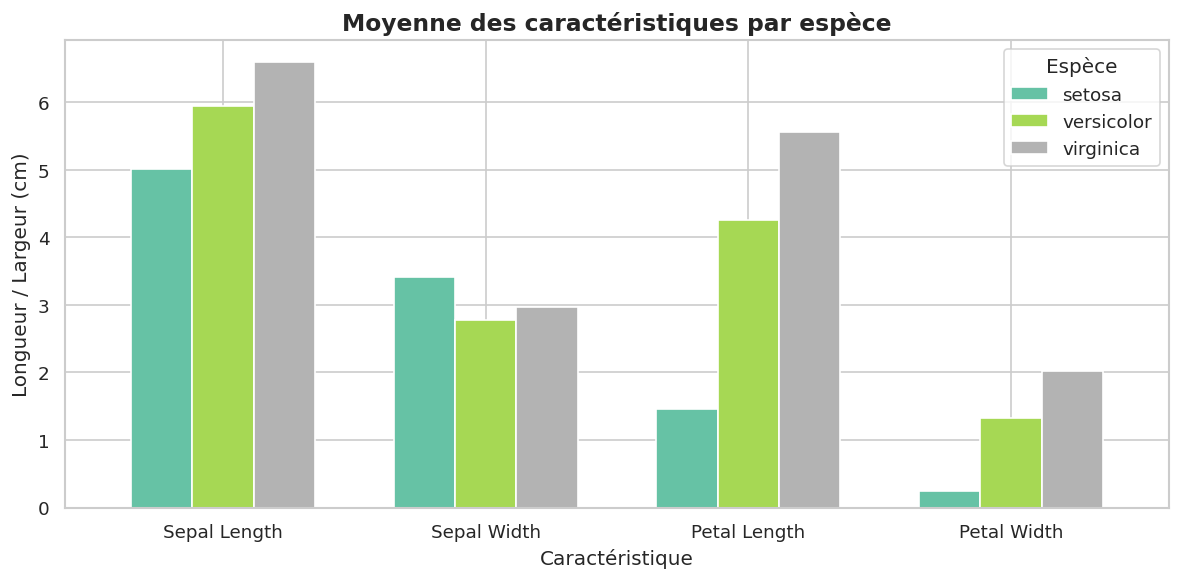

Graphique sauvegardé : outputs/barplot_iris.png


In [26]:
print("=" * 50)
print("BAR PLOT — Moyenne par espèce")
print("=" * 50)

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 5))
means.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)

# Personnalisation
ax.set_title("Moyenne des caractéristiques par espèce", fontsize=14, fontweight='bold')
ax.set_xlabel("Caractéristique", fontsize=12)
ax.set_ylabel("Longueur / Largeur (cm)", fontsize=12)
ax.set_xticklabels(['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'], rotation=0)
ax.legend(title='Espèce', bbox_to_anchor=(1, 1))

# Export
plt.tight_layout()
plt.savefig('outputs/barplot_iris.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/barplot_iris.png")

SCATTER PLOT — Sepal vs Petal


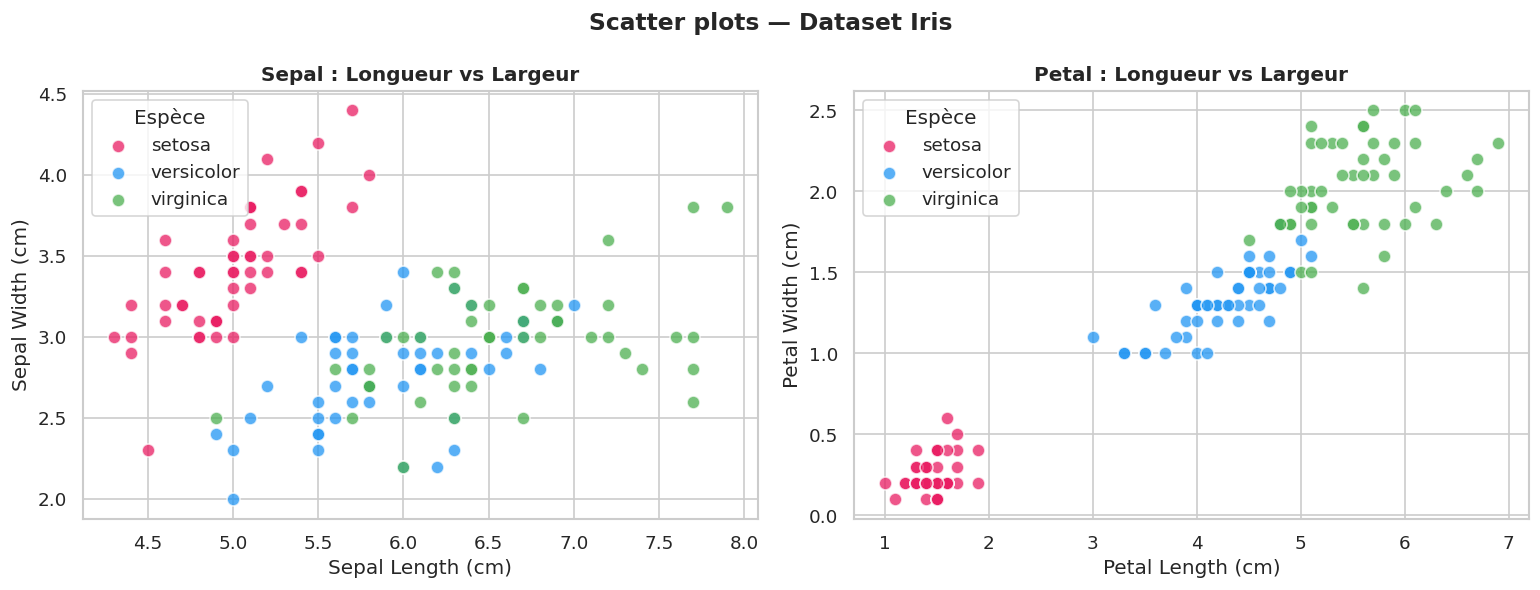

Graphique sauvegardé : outputs/scatter_iris.png


In [29]:
print("=" * 50)
print("SCATTER PLOT — Sepal vs Petal")
print("=" * 50)

palette = {'setosa': '#E91E63', 'versicolor': '#2196F3', 'virginica': '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter 1 : Sepal
for species, color in palette.items():
    subset = df[df['species'] == species]
    axes[0].scatter(subset['sepal_length'], subset['sepal_width'],
                    label=species, color=color,
                    alpha=0.75, edgecolors='white', s=60)

axes[0].set_title("Sepal : Longueur vs Largeur", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")
axes[0].legend(title="Espèce")

# Scatter 2 : Petal
for species, color in palette.items():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['petal_length'], subset['petal_width'],
                    label=species, color=color,
                    alpha=0.75, edgecolors='white', s=60)

axes[1].set_title("Petal : Longueur vs Largeur", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].legend(title="Espèce")

# Export
plt.suptitle("Scatter plots — Dataset Iris", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/scatter_iris.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/scatter_iris.png")

LINE CHART — Évolution des moyennes par espèce


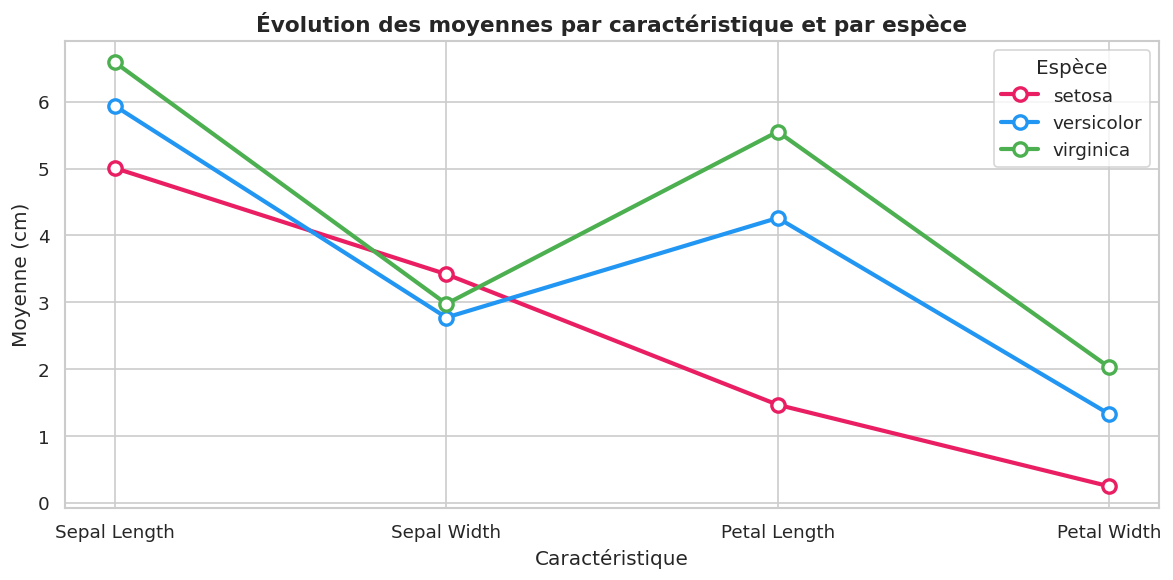

Graphique sauvegardé : outputs/linechart_iris.png


In [31]:
print("=" * 50)
print("LINE CHART — Évolution des moyennes par espèce")
print("=" * 50)

# Données : moyennes par espèce
means = df.groupby('species')[['sepal_length', 'sepal_width',
                                'petal_length', 'petal_width']].mean()

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
labels    = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

fig, ax = plt.subplots(figsize=(10, 5))

for species, color in palette.items():
    ax.plot(labels, means.loc[species, features],
            marker='o', label=species, color=color,
            linewidth=2.5, markersize=8,
            markerfacecolor='white', markeredgewidth=2)

# Personnalisation
ax.set_title("Évolution des moyennes par caractéristique et par espèce",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Caractéristique", fontsize=12)
ax.set_ylabel("Moyenne (cm)", fontsize=12)
ax.legend(title="Espèce")

# Export
plt.tight_layout()
plt.savefig('outputs/linechart_iris.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/linechart_iris.png")

BOXPLOT — Distribution par espèce


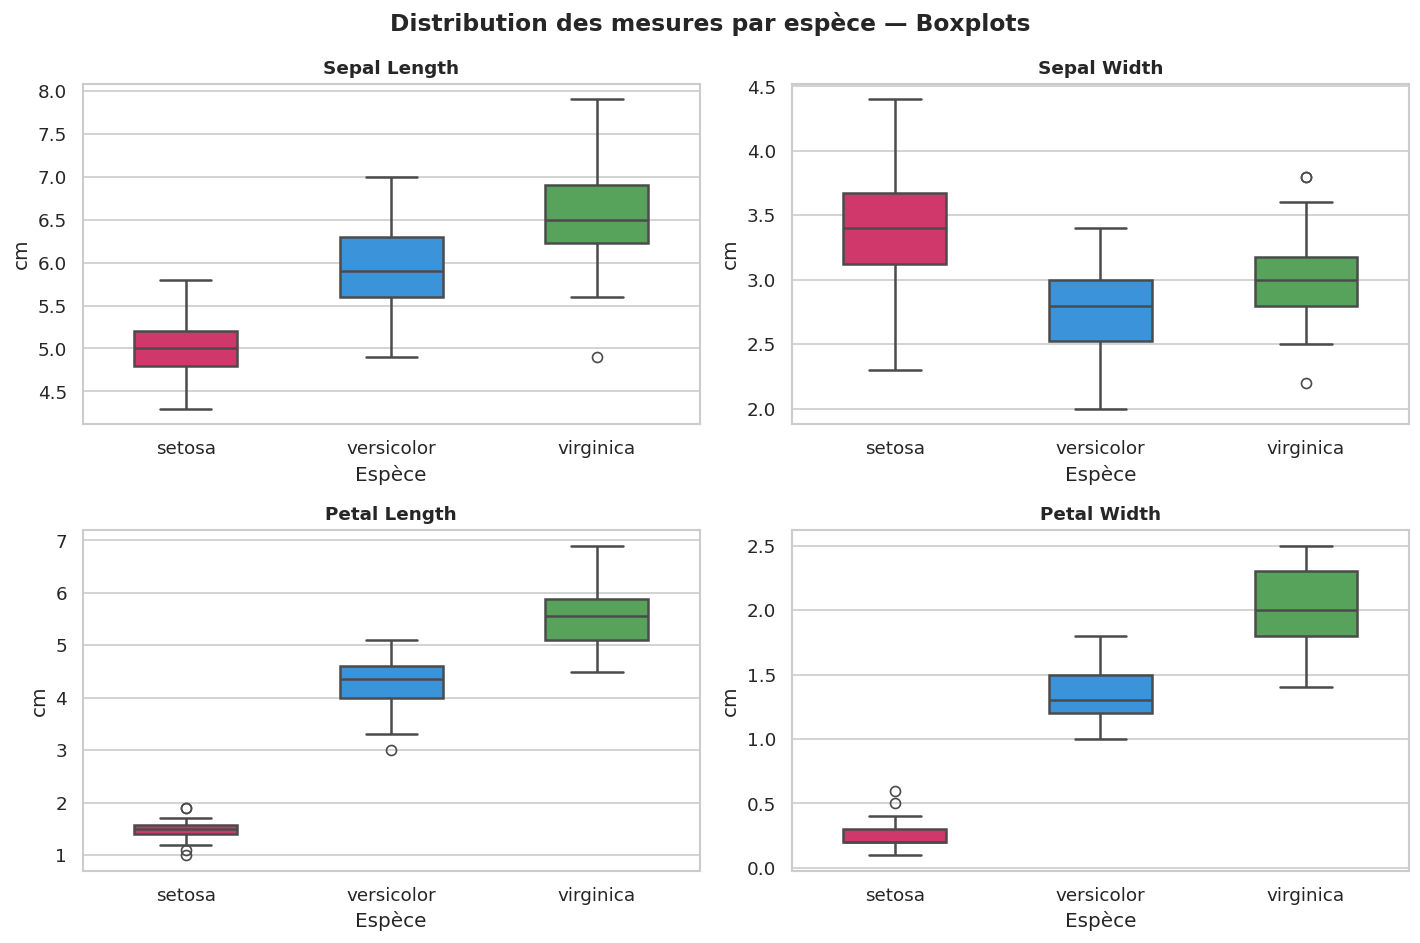

Graphique sauvegardé : outputs/boxplot_iris.png


In [32]:
print("=" * 50)
print("BOXPLOT — Distribution par espèce")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colonnes = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titres   = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

for i, (col, titre) in enumerate(zip(colonnes, titres)):
    sns.boxplot(data=df, x='species', y=col,
                palette=palette, ax=axes[i],
                width=0.5, linewidth=1.5)
    axes[i].set_title(titre, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Espèce")
    axes[i].set_ylabel("cm")

plt.suptitle("Distribution des mesures par espèce — Boxplots",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/boxplot_iris.png', bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : outputs/boxplot_iris.png")